# RESTOPS · Turn identified visits into a retention worklist

In [1]:
from pathlib import Path
import json
import os
import sys

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache/matplotlib"))
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
from src.common import read, TABLEAU, REPORTS
from src.reporting import style
style()
pd.set_option("display.max_columns", 12)


**Business question:** Which customer behaviours justify a retention experiment?

Separate the RFM snapshot from acquisition-style cohorts. First observed visit is not proven first-ever visit, and anonymous visitors remain outside these rates.

In [2]:
customers = read("customer_segments", TABLEAU)
customers.groupby("segment").agg(customers=("customer_id", "size"), mean_recency=("recency_days", "mean"), mean_visits=("visits", "mean"), spend=("spend", "sum"))

,customers,mean_recency,mean_visits,spend
segment,,,,
Champions,5954,11.917031,28.488243,8168308.73
Developing,8625,42.518145,4.008812,1591117.93
Lapsed,20988,225.790976,5.096960,4922907.68
New / occasional,368,14.336957,1.820652,31084.34
Regulars,17719,39.092612,9.654608,7915833.25


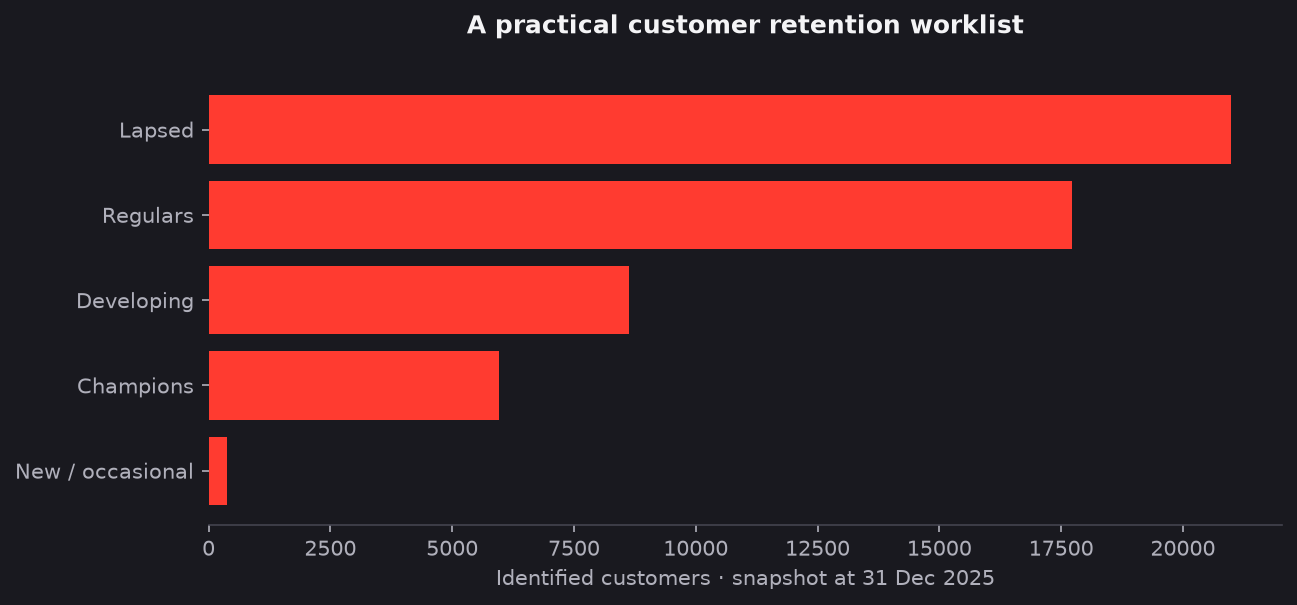

In [3]:
display(Image(filename=str(REPORTS / "figures/customer_segments.png")))

In [4]:
cohorts = read("customer_cohorts", TABLEAU)
cohort_summary = cohorts.groupby("cohort_month")[["eligible_customers", "repeat_customers"]].sum()
cohort_summary["repeat_rate"] = cohort_summary.repeat_customers / cohort_summary.eligible_customers.replace(0, float("nan"))
cohort_summary.tail(8)

,eligible_customers,repeat_customers,repeat_rate
cohort_month,,,
2025-05,252,105.0,0.416667
2025-06,193,82.0,0.424870
2025-07,170,84.0,0.494118
2025-08,131,53.0,0.404580
2025-09,123,65.0,0.528455
2025-10,2,0.0,0.000000
2025-11,0,0.0,NaN
2025-12,0,0.0,NaN


In [5]:
read("loyalty_behaviours", TABLEAU)

,early_activity_band,early_redemption,customers,later_returners,later_return_rate
0,1 visit,False,35614,14150.0,0.397316
1,1 visit,True,3166,1276.0,0.403032
2,2–3 visits,False,11221,5652.0,0.503698
3,2–3 visits,True,2348,1180.0,0.502555
4,4+ visits,False,679,566.0,0.833579
5,4+ visits,True,357,322.0,0.901961


In [6]:
summary = json.loads((REPORTS / "analysis_summary.json").read_text())
print(f"Eligible customers: {summary["eligible_customers"]:,}")
print(f"90-day repeat rate: {summary["repeat_customer_rate"]:.1%}")

Eligible customers: 53,385
90-day repeat rate: 56.3%


**Decision:** Test a second-visit intervention with a random holdout among low-activity customers. Early visits/redemption in days 0–30 are compared with return outcomes in days 31–90, stratified by activity. Redemption is an association, not evidence of loyalty causation.